In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")

sampler_instance = None  # injected before run_sampling

anneal_state = {
    'S': 1.0,
    'phase': 'normal',           # 'normal' | 'waiting' | 'annealing'
    'phase_start_iter': None,    # iter when current phase began
    'ref_unscaled_max_ld': None, # unscaled max_ld at start of current interval
    'ref_iter': None,            # iter when ref_unscaled_max_ld was recorded
}


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0])) * anneal_state['S']
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    return transformed

def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    params = np.asarray(params)
    u = np.zeros_like(params)

    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])

    return u



print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_anneal10/sampler_state.pkl')

In [3]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [4]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.537553  , 0.642705  , 0.549253  , 0.373063  , 0.397031  ],
        [0.53756087, 0.64271595, 0.54924315, 0.37305137, 0.39704231],
        [0.53754599, 0.64269731, 0.54925608, 0.37305516, 0.39702619],
        ...,
        [0.49242554, 0.37497175, 0.57230152, 0.34701805, 0.69536892],
        [0.51488215, 0.4213652 , 0.60990593, 0.29315223, 0.64139301],
        [0.52272631, 0.41096871, 0.63660677, 0.26387635, 0.65265218]],
       shape=(100000, 5))]

In [5]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([ 2.02502927,  2.02448539,  2.01759835, ..., 55.2545639 ,
        57.38809335, 53.54784156], shape=(100000,))]

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1


array([[6.01404269, 1.00358398, 0.73114047, 8.82236913, 0.39638559]])

In [7]:
log_density(maxld_pt1)

array([5.9010809])

In [ ]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [9]:
gwf.rhostat(h_pt1)

array(5.99852272)

In [10]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(5.92598733), array(5.87850066))

In [11]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

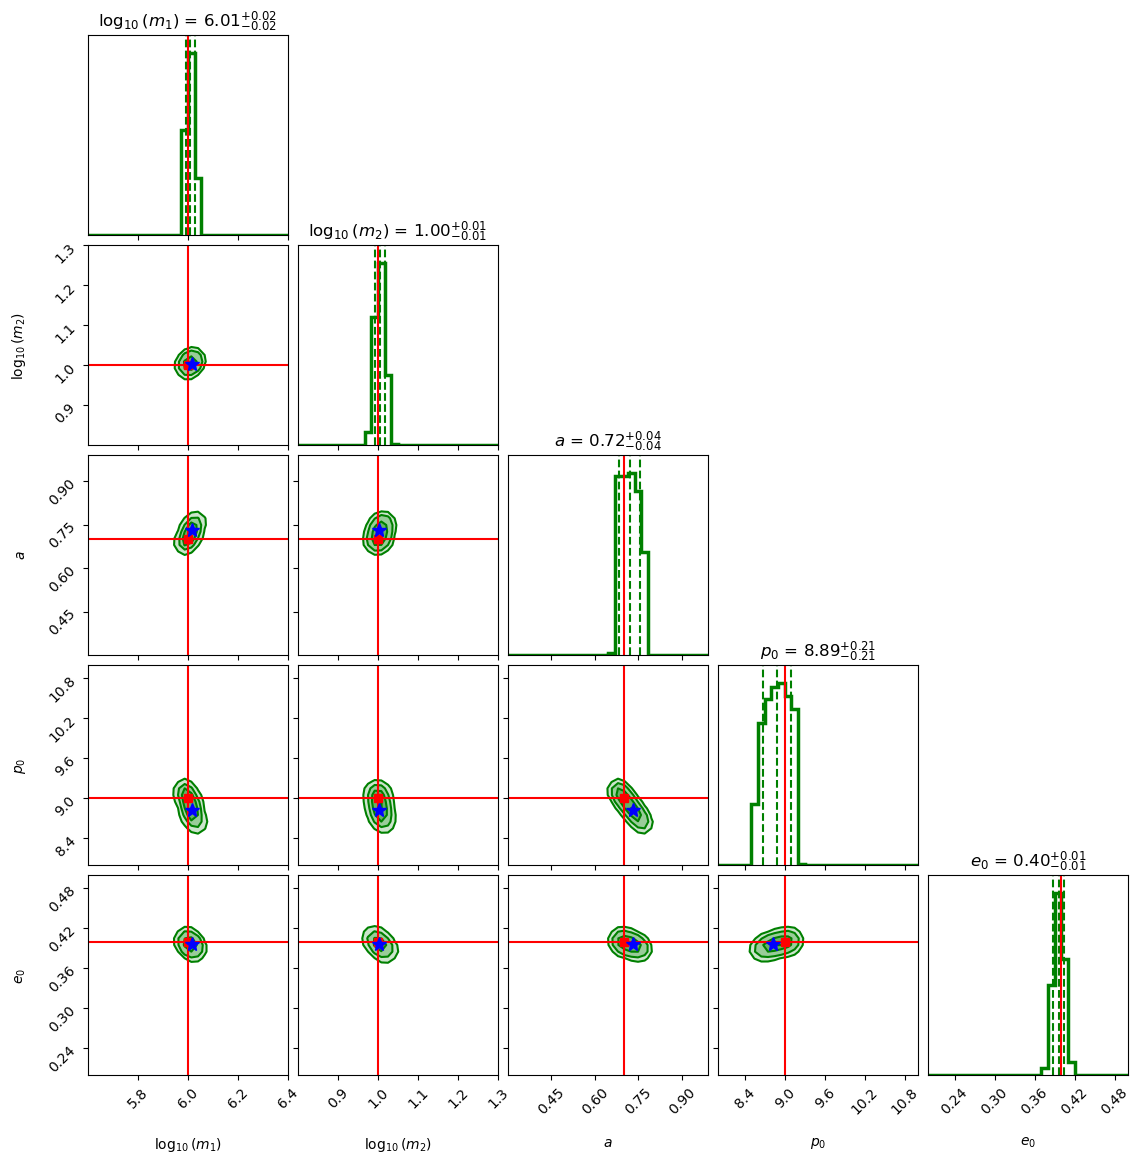

In [12]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




# connection plots

In [13]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [14]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.01404269, 1.00358398, 0.73114047, 8.82236913, 0.39638559]])

In [17]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)
# n_points=100

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]

#NOTE: extended plots till it hits prior boundaries

# prior_lo = np.array([r[0] for r in param_ranges])
# prior_hi = np.array([r[1] for r in param_ranges])

# start = proc1_maxld_pt_1d
# direction = true_pt - proc1_maxld_pt_1d
# # Per-dimension line points spanning each param's full prior
# line_points_per_dim = []
# for i in range(5):
#     if direction[i] > 0:
#         t_lo = (prior_lo[i] - start[i]) / direction[i]
#         t_hi = (prior_hi[i] - start[i]) / direction[i]
#     elif direction[i] < 0:
#         t_lo = (prior_hi[i] - start[i]) / direction[i]
#         t_hi = (prior_lo[i] - start[i]) / direction[i]
#     else:
#         t_lo, t_hi = 0, 1
#     t_vals = np.linspace(t_lo, t_hi, n_points)
#     line_points_per_dim.append(start[:, np.newaxis] + t_vals * direction[:, np.newaxis])



In [18]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [21]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()
logden_theory_proc1

array([5.9010809 , 5.70395399, 5.88776626, 5.80114891, 5.81733988,
       5.88408583, 5.67878556, 5.85433556, 5.86744365, 5.69162845,
       5.8085828 , 5.87751747, 5.81487289, 5.65242749, 5.77356366,
       5.85231568, 5.86129987, 5.82319658, 5.7526236 , 5.66574481,
       5.65341111, 5.71445993, 5.752302  , 5.77375251, 5.78331574,
       5.78307095, 5.77265612, 5.74927234, 5.70773713, 5.64537938,
       5.67781685, 5.76422241, 5.83203794, 5.86623258, 5.84939105,
       5.76237343, 5.67279523, 5.82836316, 5.8819882 , 5.80155396,
       5.71164657, 5.87667108, 5.85272626, 5.69533812, 5.8904372 ,
       5.81660937, 5.80609532, 5.89215384, 5.70038778, 5.90712146])

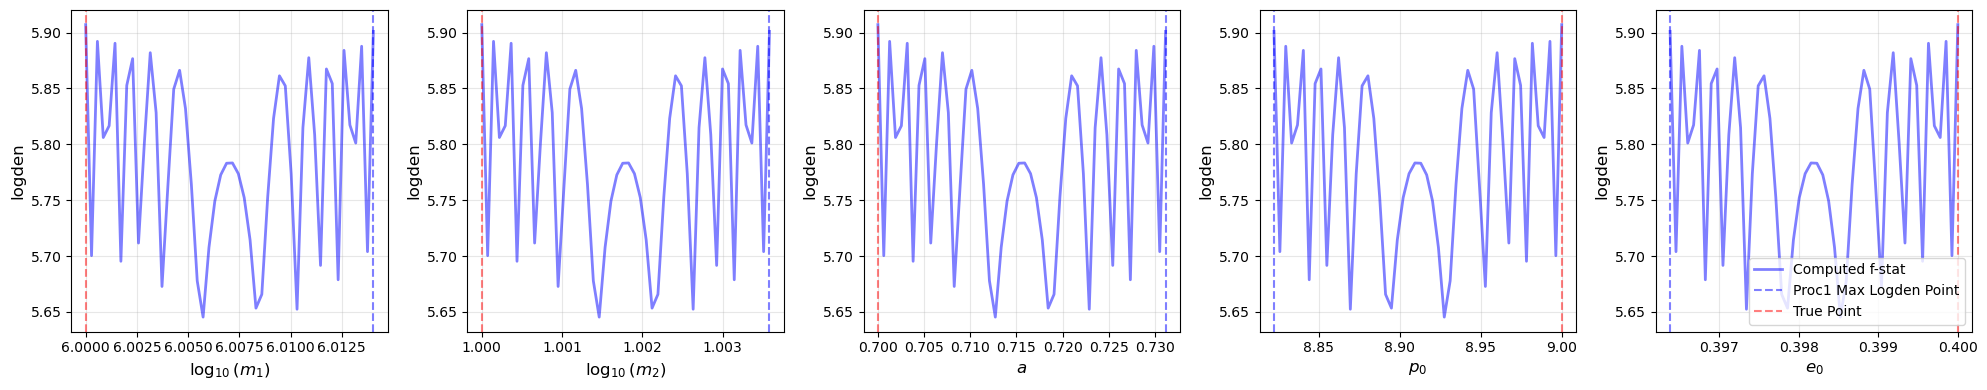

In [22]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [23]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [24]:
X_proc1 = []
for template in templates_proc1:
    X = gwf.Xstat_timemax(data, template)
    X_proc1.append(X.get())

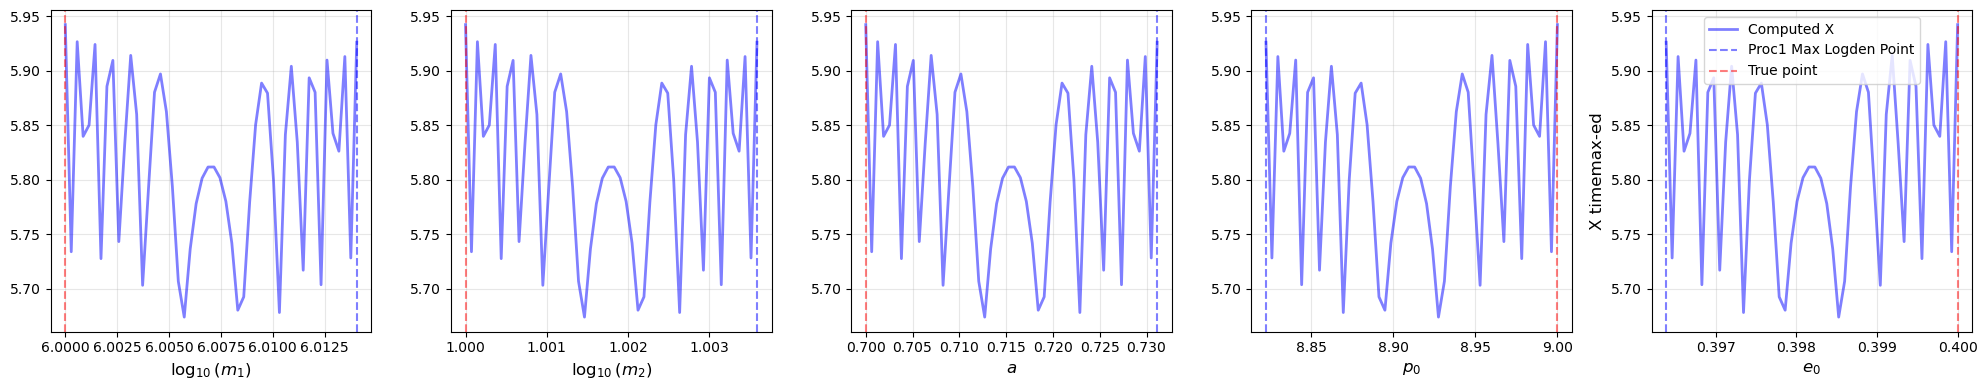

In [25]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('X timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [26]:
X_proc1_nont = []
for template in templates_proc1:
    X = gwf.Xstat(data, template)
    X_proc1_nont.append(X.get())

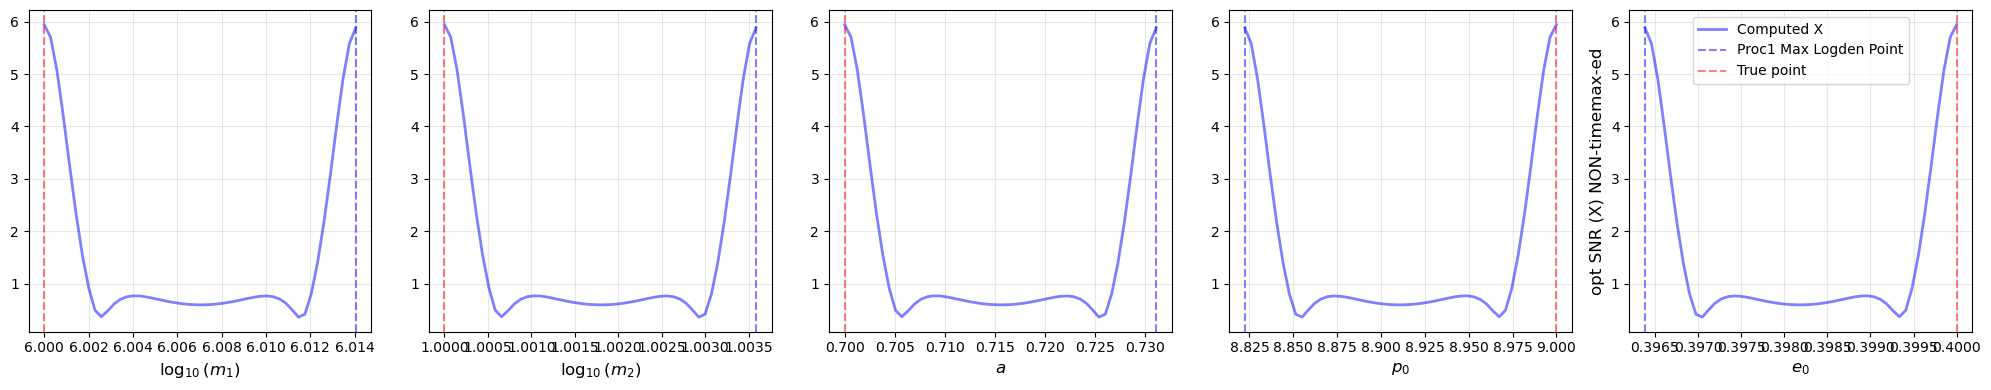

In [27]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X) NON-timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_nont, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [30]:
prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
# Per-dimension line points spanning each param's full prior
line_points_per_dim = []
for i in range(5):
    if direction[i] > 0:
        t_lo = (prior_lo[i] - start[i]) / direction[i]
        t_hi = (prior_hi[i] - start[i]) / direction[i]
    elif direction[i] < 0:
        t_lo = (prior_hi[i] - start[i]) / direction[i]
        t_hi = (prior_lo[i] - start[i]) / direction[i]
    else:
        t_lo, t_hi = 0, 1
    t_vals = np.linspace(t_lo, t_hi, n_points)
    line_points_per_dim.append(start[:, np.newaxis] + t_vals * direction[:, np.newaxis])


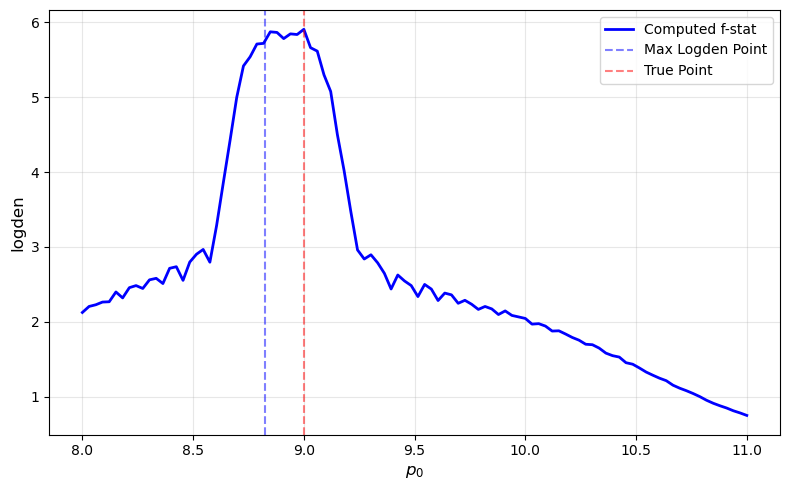

In [31]:
i = 3  # p0
if direction[i] > 0:
    t_lo_p0 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_p0 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_p0 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_p0 = (prior_lo[i] - start[i]) / direction[i]

n_points = 100
t_values_p0 = np.linspace(t_lo_p0, t_hi_p0, n_points)
line_points_p0 = start[:, np.newaxis] + t_values_p0 * direction[:, np.newaxis]

logden_p0 = log_density(line_points_p0.T)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_p0[3], logden_p0, '-', color='blue', linewidth=2, label='Computed f-stat')
ax.axvline(proc1_maxld_pt_1d[3], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[3],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$p_0$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

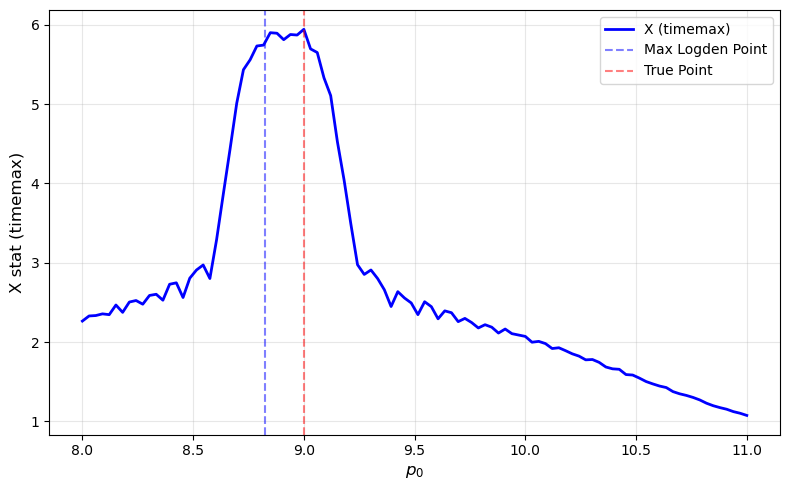

In [ ]:
X_p0_tmax = []
for point in line_points_p0.T:
    logm1, logm2, a, p0, e0 = point
    template = waveform_gen_comb(
        10**logm1, 10**logm2, a, p0, e0,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
        dt=dt, T=T
    )
    X_p0_tmax.append(gwf.Xstat_timemax(data, template).get())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_p0[3], X_p0_tmax, '-', color='blue', linewidth=2, label='X (timemax)')
ax.axvline(proc1_maxld_pt_1d[3], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[3],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$p_0$', fontsize=12)
ax.set_ylabel('X stat', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

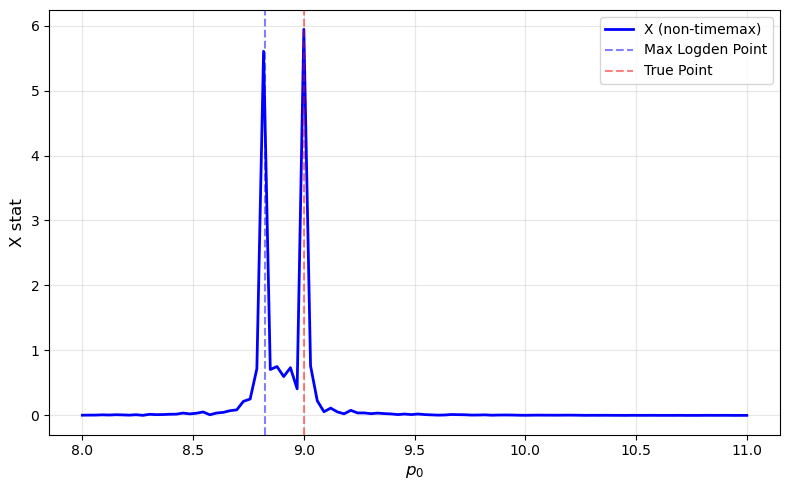

In [32]:
X_p0_nont = []
for point in line_points_p0.T:
    logm1, logm2, a, p0, e0 = point
    template = waveform_gen_comb(
        10**logm1, 10**logm2, a, p0, e0,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
        dt=dt, T=T
    )
    X_p0_nont.append(gwf.Xstat(data, template).get())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_p0[3], X_p0_nont, '-', color='blue', linewidth=2, label='X (non-timemax)')
ax.axvline(proc1_maxld_pt_1d[3], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[3],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$p_0$', fontsize=12)
ax.set_ylabel('X stat', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [34]:
import loglike 
loglike_nont = loglike.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

In [35]:
def log_density_nont(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2
        try:
            loglike = loglike_nont(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

In [37]:
logden_p0_nont = log_density_nont(line_points_p0.T)


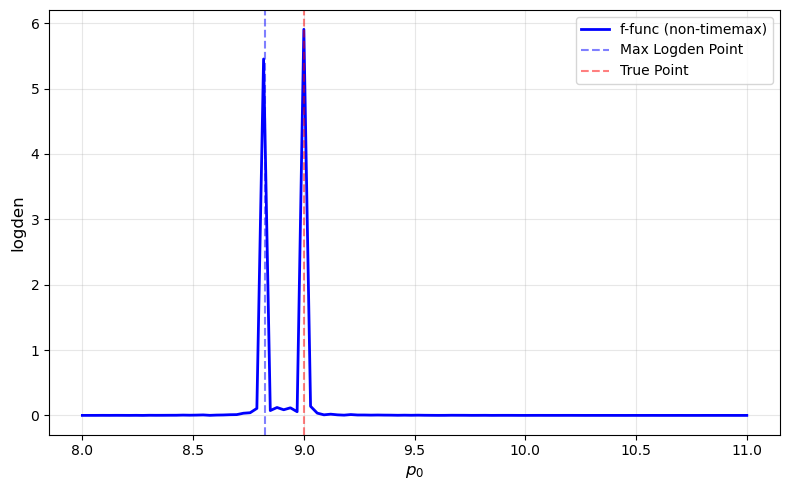

In [38]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_p0[3], logden_p0_nont, '-', color='blue', linewidth=2, label='f-func (non-timemax)')
ax.axvline(proc1_maxld_pt_1d[3], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[3],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$p_0$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

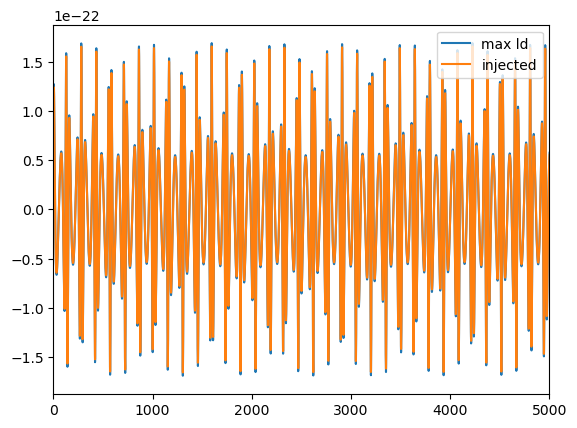

In [47]:
plt.plot(h_pt1.get().real, label='max ld')
plt.plot(data.get().real, label='injected')

plt.xlim(0,5e3)
plt.legend()
plt.show()

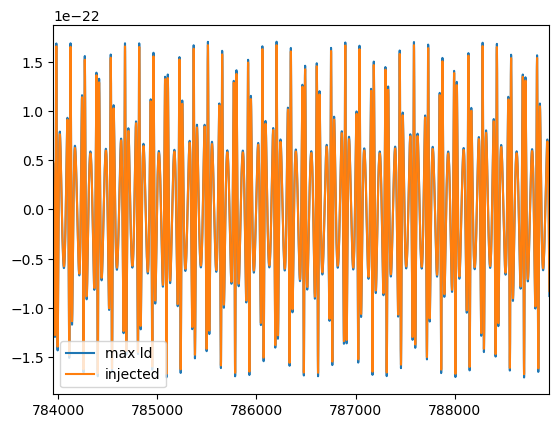

In [48]:
plt.plot(h_pt1.get().real, label='max ld')
plt.plot(data.get().real, label='injected')

plt.xlim(len(data)-5e3,len(data))
plt.legend()
plt.show()